In [41]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 12.2 MB/s eta 0:00:09
   - -------------------------------------- 4.7/101.7 MB 11.4 MB/s eta 0:00:09
   -- ------------------------------------- 6.8/101.7 MB 11.3 MB/s eta 0:00:09
   --- ------------------------------------ 9.2/101.7 MB 11.2 MB/s eta 0:00:09
   ---- ----------------------------------- 11.5/101.7 MB 11.1 MB/s eta 0:00:09
   ----- ---------------------------------- 13.9/101.7 MB 11.0 MB/s eta 0:00:08
   ------ --------------------------------- 16.3/101.7 MB 11.0 MB/s eta 0:00:08
   ------- -------------------------------- 18.4/101.7 MB 11.0 MB/s eta 0:00:08
   -------- ------------------------------- 20.7/101.7 MB 11.0 MB/s eta 0:00:08
   --------- ------------------------------ 23.1/101.7 MB 11.0 MB/s eta 0:00:08
   --------- ------------------------------ 24.9/101.7 MB 11.0 MB/s eta 0:00:07
   ---------- ----------------------------- 27.5/101.

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('loan_approval_dataset.csv')
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df = df.drop(columns = ['loan_id'])

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df.shape

(4269, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   object
 2   self_employed             4269 non-null   object
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(9), object(3)
memory usage: 400.3+ KB


In [8]:
num_col = df.select_dtypes(include = ['number']).columns.to_list()

In [9]:
cat_col = df.select_dtypes(include = ['object']).columns.tolist()

In [10]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [11]:
num_col, cat_col

(['no_of_dependents',
  'income_annum',
  'loan_amount',
  'loan_term',
  'cibil_score',
  'residential_assets_value',
  'commercial_assets_value',
  'luxury_assets_value',
  'bank_asset_value'],
 ['education', 'self_employed', 'loan_status'])

In [12]:
df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [15]:
df.describe(include='object')

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


<Axes: xlabel='income_annum', ylabel='Count'>

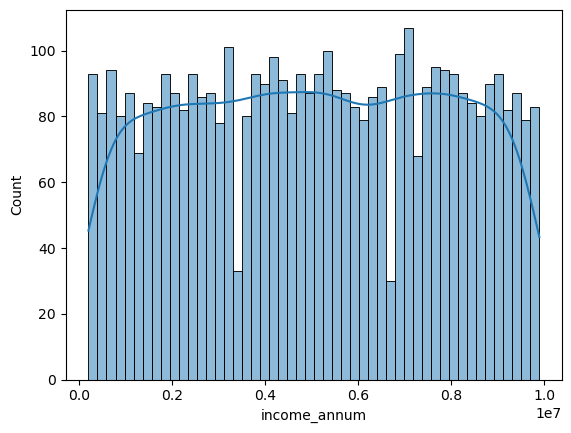

In [16]:
sns.histplot(data=df, x = 'income_annum',bins=50, kde=True)

In [17]:
df['no_of_dependents'].value_counts()

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

<Axes: xlabel='no_of_dependents', ylabel='Count'>

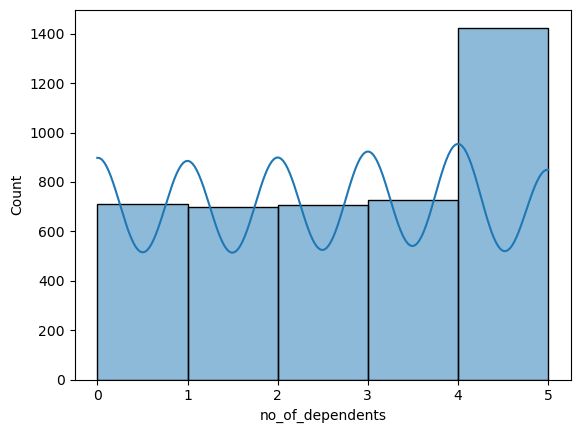

In [18]:
sns.histplot(data=df, x = 'no_of_dependents',bins=5, kde=True)

In [19]:
for col in num_col: 
    print(df[col].value_counts())
    print('--'*50)

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
income_annum
7000000    62
4100000    59
7600000    57
4700000    56
5300000    55
           ..
3600000    33
3400000    33
9300000    33
8500000    32
6700000    30
Name: count, Length: 98, dtype: int64
----------------------------------------------------------------------------------------------------
loan_amount
10600000    27
20000000    24
9400000     24
23900000    23
16800000    23
            ..
33400000     1
36600000     1
33800000     1
37700000     1
36100000     1
Name: count, Length: 378, dtype: int64
----------------------------------------------------------------------------------------------------
loan_term
6     490
12    456
4     447
10    436
18    422
16    412
20    411
14    405
2     404
8     386
Name: count, dtype: int64
-------------------------------------------

<Axes: xlabel='loan_term', ylabel='Count'>

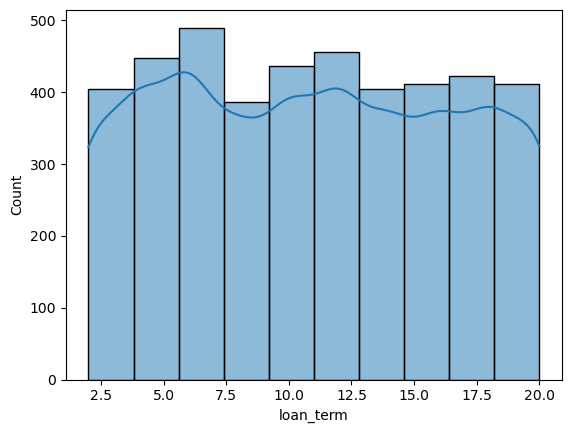

In [20]:
sns.histplot(data=df, x = 'loan_term',bins=10, kde=True)

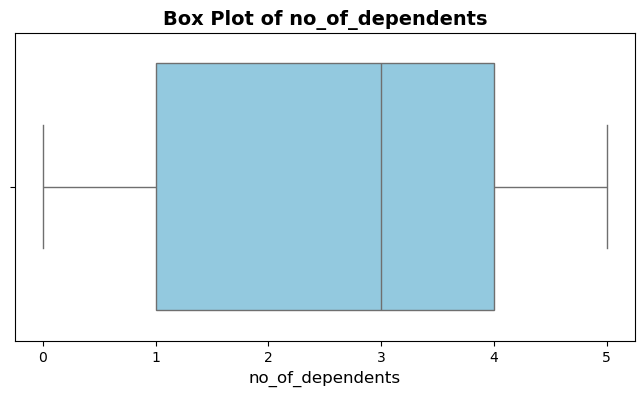

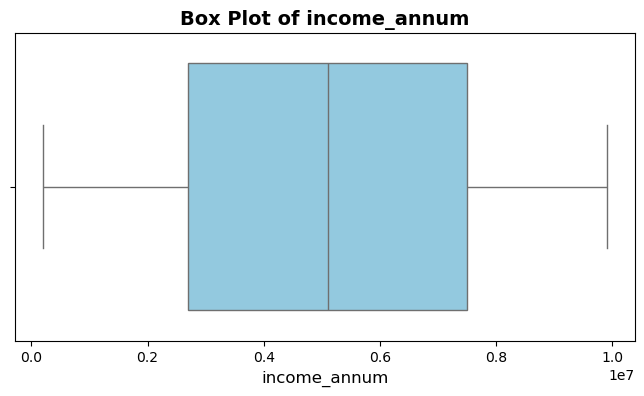

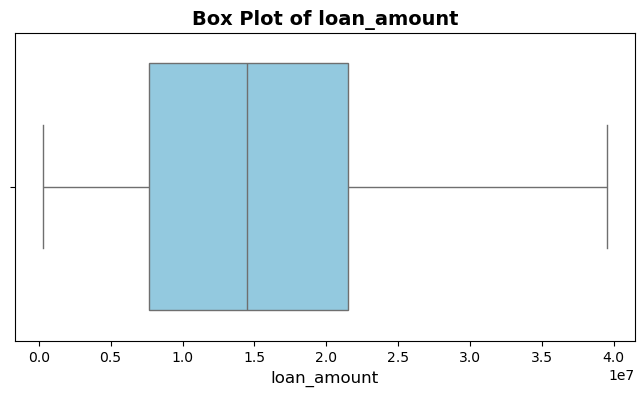

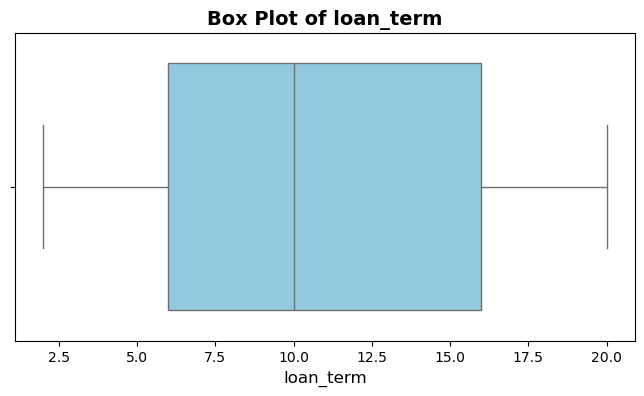

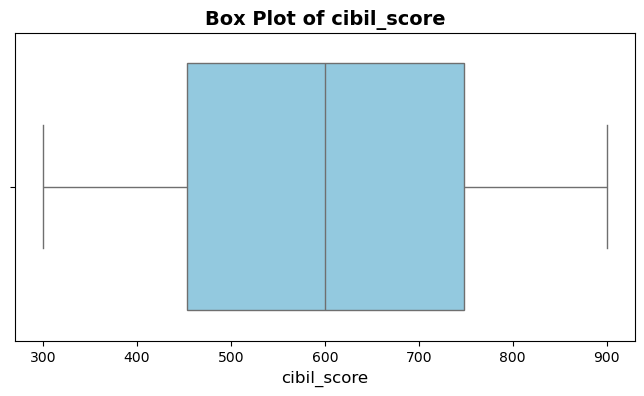

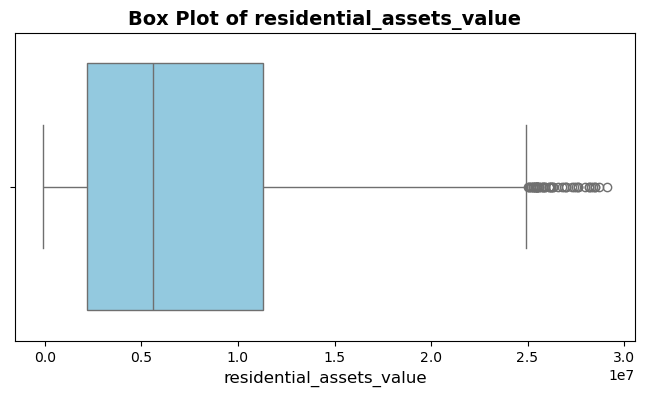

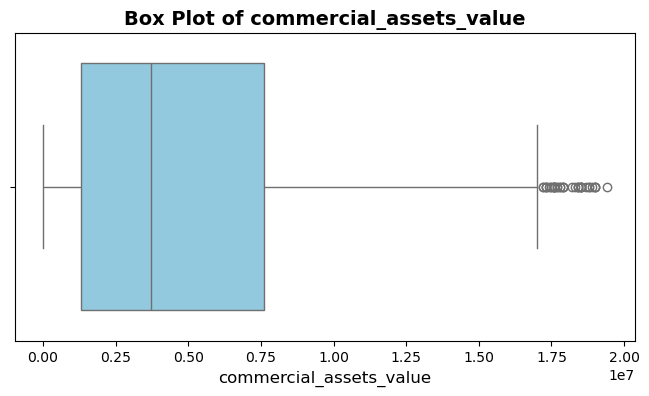

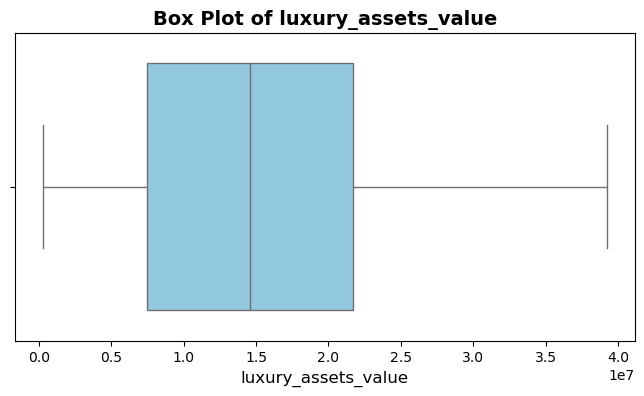

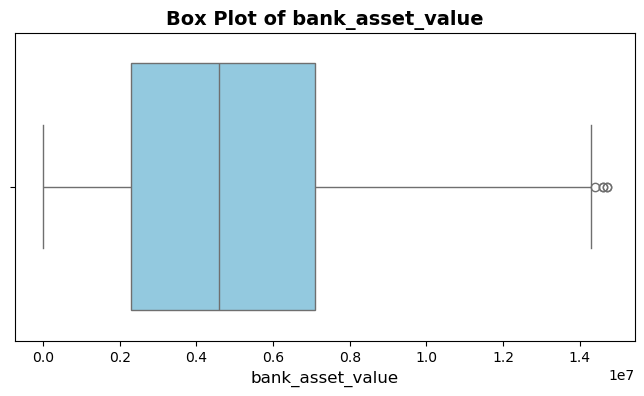

In [21]:
for col in num_col:
    plt.figure(figsize=(8, 4))  # Sets a nice, wide size for each plot
    
    sns.boxplot(data=df, x=col, color='skyblue')
    
    plt.title(f'Box Plot of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    
    plt.show()

In [22]:
assets_value = num_col[5:]
assets_value

['residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

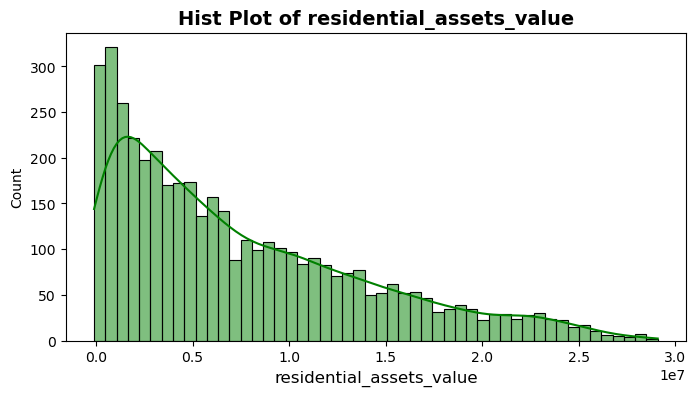

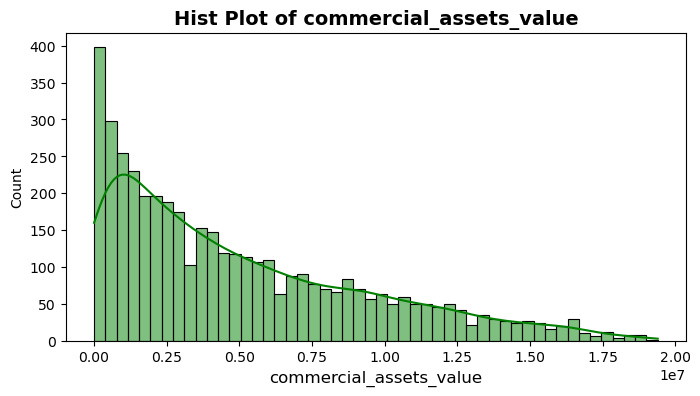

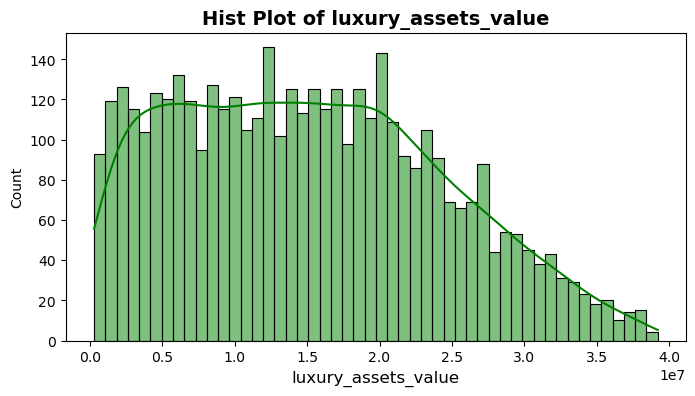

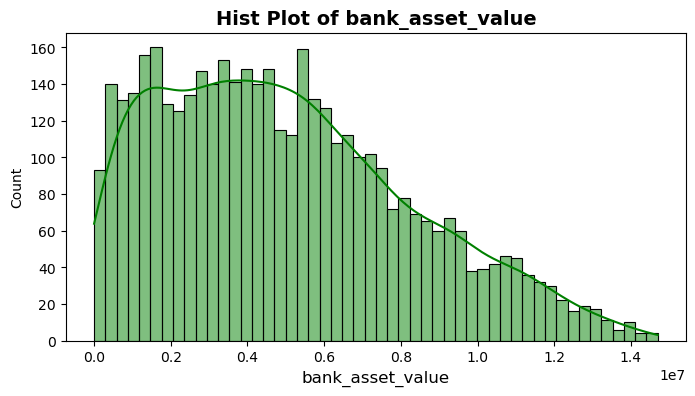

In [23]:
for col in assets_value:
    plt.figure(figsize=(8, 4))  # Sets a nice, wide size for each plot
    
    sns.histplot(data=df, x=col, bins=50,kde=True ,color='green')
    
    plt.title(f'Hist Plot of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    
    plt.show()

In [24]:
print(df[assets_value].skew())

residential_assets_value    0.978451
commercial_assets_value     0.957791
luxury_assets_value         0.322208
bank_asset_value            0.560725
dtype: float64


In [25]:
# Apply log transformation to the highly skewed columns
df['residential_assets_value_log'] = np.log1p(df['residential_assets_value'])
df['commercial_assets_value_log'] = np.log1p(df['commercial_assets_value'])

# Drop the old, skewed columns so the model doesn't get confused
df = df.drop(columns=['residential_assets_value', 'commercial_assets_value'])

In [26]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,luxury_assets_value,bank_asset_value,loan_status,residential_assets_value_log,commercial_assets_value_log
0,2,Graduate,No,9600000,29900000,12,778,22700000,8000000,Approved,14.690980,16.683410
1,0,Not Graduate,Yes,4100000,12200000,8,417,8800000,3300000,Rejected,14.808763,14.603968
2,3,Graduate,No,9100000,29700000,20,506,33300000,12800000,Rejected,15.775605,15.319588
3,3,Graduate,No,8200000,30700000,8,467,23300000,7900000,Rejected,16.716932,15.009433
4,5,Not Graduate,Yes,9800000,24200000,20,382,29400000,5000000,Rejected,16.333207,15.919645


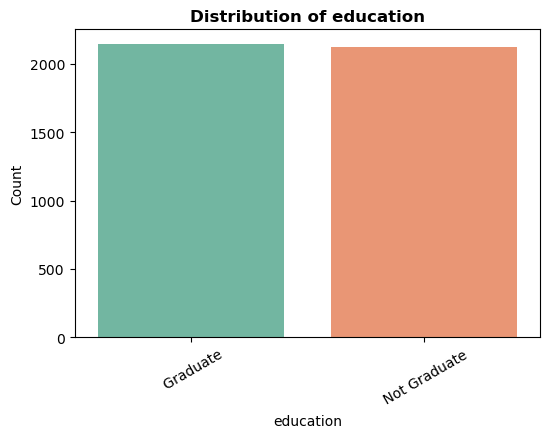

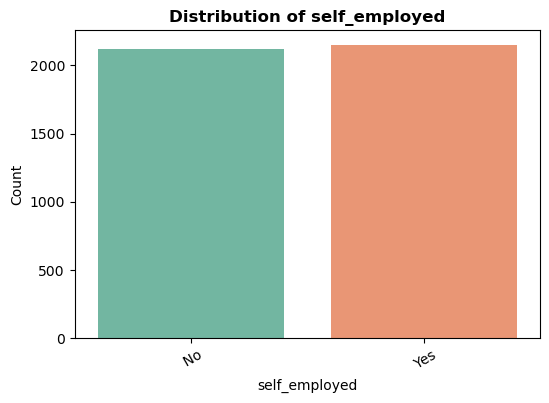

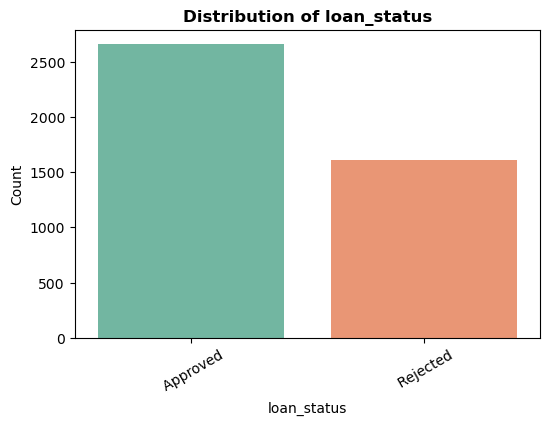

In [27]:
for col in cat_col:
    plt.figure(figsize=(6, 4))  # Standard, manageable size

    # Create the basic bar count
    sns.countplot(data=df, x=col, palette="Set2")

    plt.title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)  # Tilts the labels slightly so they don't overlap

    plt.show()

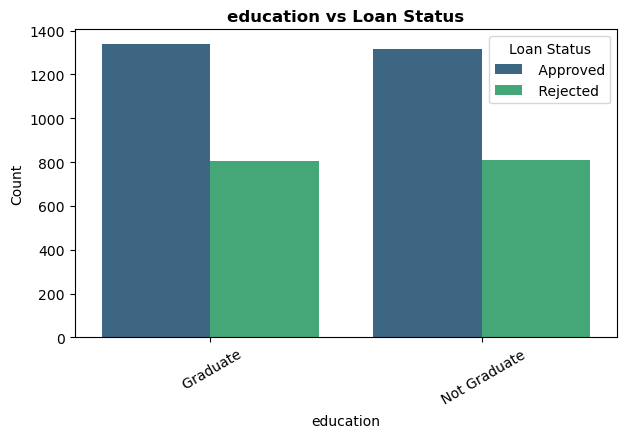

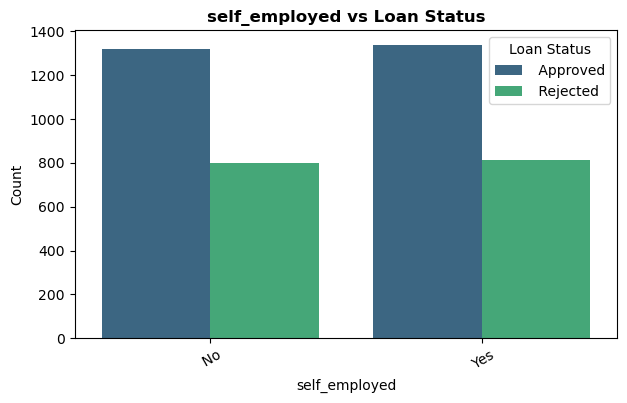

In [28]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
cat_cols = [col for col in cat_cols if col != 'loan_status']

# 2. Loop and plot them against the target
for col in cat_cols:
    plt.figure(figsize=(7, 4))
    
    # 'hue' splits the bars by the loan status
    sns.countplot(data=df, x=col, hue='loan_status', palette='viridis')
    
    plt.title(f'{col} vs Loan Status', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.legend(title='Loan Status')
    
    plt.show()

In [29]:
# Use regex=True to find 'Yes' or 'Graduate' even if they have hidden spaces around them
df["self_employed"] = df["self_employed"].replace(
    {r"^\s*Yes\s*$": 1, r"^\s*No\s*$": 0}, regex=True
)
df["education"] = df["education"].replace(
    {r"^\s*Graduate\s*$": 1, r"^\s*Not Graduate\s*$": 0}, regex=True
)

# Quick sanity check
print(df[["self_employed", "education"]].head())

   self_employed  education
0              0          1
1              1          0
2              0          1
3              0          1
4              1          0


In [30]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,luxury_assets_value,bank_asset_value,loan_status,residential_assets_value_log,commercial_assets_value_log
0,2,1,0,9600000,29900000,12,778,22700000,8000000,Approved,14.690980,16.683410
1,0,0,1,4100000,12200000,8,417,8800000,3300000,Rejected,14.808763,14.603968
2,3,1,0,9100000,29700000,20,506,33300000,12800000,Rejected,15.775605,15.319588
3,3,1,0,8200000,30700000,8,467,23300000,7900000,Rejected,16.716932,15.009433
4,5,0,1,9800000,24200000,20,382,29400000,5000000,Rejected,16.333207,15.919645


In [32]:
df['loan_status'] = df['loan_status'].str.strip()

In [33]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,luxury_assets_value,bank_asset_value,loan_status,residential_assets_value_log,commercial_assets_value_log
0,2,1,0,9600000,29900000,12,778,22700000,8000000,Approved,14.690980,16.683410
1,0,0,1,4100000,12200000,8,417,8800000,3300000,Rejected,14.808763,14.603968
2,3,1,0,9100000,29700000,20,506,33300000,12800000,Rejected,15.775605,15.319588
3,3,1,0,8200000,30700000,8,467,23300000,7900000,Rejected,16.716932,15.009433
4,5,0,1,9800000,24200000,20,382,29400000,5000000,Rejected,16.333207,15.919645


In [34]:
df.dtypes

no_of_dependents                  int64
education                         int64
self_employed                     int64
income_annum                      int64
loan_amount                       int64
loan_term                         int64
cibil_score                       int64
luxury_assets_value               int64
bank_asset_value                  int64
loan_status                      object
residential_assets_value_log    float64
commercial_assets_value_log     float64
dtype: object

In [35]:
print(df['loan_status'].unique())

['Approved' 'Rejected']


In [36]:
df['loan_status'] = df['loan_status'].map({'Approved': 1 , 'Rejected': 0 })

In [37]:
X = df.drop(columns = ['loan_status'])

In [38]:
y = df['loan_status']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [42]:
from xgboost import XGBClassifier

# Initialize the model
model = XGBClassifier(random_state=42, eval_metric='logloss')

# Train it!
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [43]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
y_pred = model.predict(X_test)

# Print the final report card
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Confusion Matrix ---
[[315   8]
 [  7 524]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [45]:
X.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'luxury_assets_value',
       'bank_asset_value', 'residential_assets_value_log',
       'commercial_assets_value_log'],
      dtype='object')

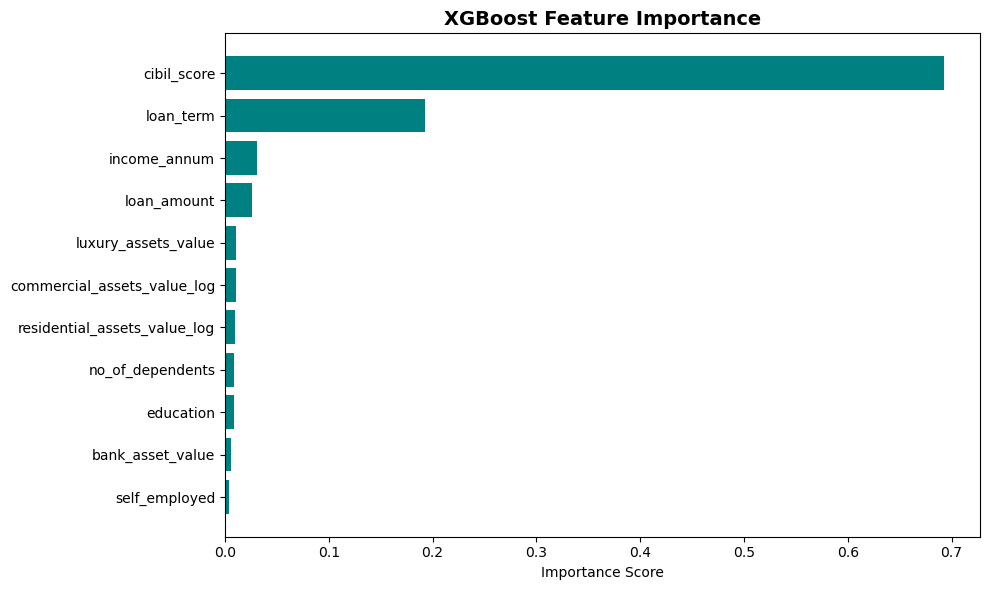

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get feature importances from the trained model
importances = model.feature_importances_

# 2. Match them with the column names
feature_imp_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})

# 3. Sort them from highest to lowest
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=True)

# 4. Plot a clean horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(
    feature_imp_df["Feature"], feature_imp_df["Importance"], color="teal"
)
plt.xlabel("Importance Score")
plt.title("XGBoost Feature Importance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [48]:
import numpy as np

# Replace positive/negative infinity values with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Fill all NaNs with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# 1. Initialize the models
# (We wrap Logistic Regression in a pipeline with StandardScaler so the numbers don't break it)
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
}

# 2. Loop through, train, and collect accuracy scores
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    results[name] = acc

# 3. Print the Leaderboard
print("=== MODEL LEADERBOARD ===")
print(f"XGBoost             : 0.982  (Your previous score)") # approximate from your matrix
for name, score in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name:<20}: {score:.3f}")

=== MODEL LEADERBOARD ===
XGBoost             : 0.982  (Your previous score)
Random Forest       : 0.985
Decision Tree       : 0.981
Logistic Regression : 0.913


In [50]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Update features and target
X_reg = df.drop(columns=["loan_amount"])
y_reg = df["loan_amount"]

# 2. Fix any infinity/NaN leftovers from the log transforms just in case
X_reg = X_reg.replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Split into train and test sets (no stratify needed for continuous targets)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# Initialize Regressors
reg_models = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(
        random_state=42, objective="reg:squarederror"
    ),
}

# Train and evaluate
reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train_r, y_train_r)
    preds = model.predict(X_test_r)
    r2 = r2_score(y_test_r, preds)
    reg_results[name] = r2

# Print Regression Leaderboard
print("=== REGRESSION LEADERBOARD (R² Score) ===")
for name, score in sorted(
    reg_results.items(), key=lambda item: item[1], reverse=True
):
    print(f"{name:<25}: {score:.4f}")

=== REGRESSION LEADERBOARD (R² Score) ===
Linear Regression        : 0.8532
Random Forest Regressor  : 0.8486
XGBoost Regressor        : 0.8290


In [52]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Use relevant numerical features for grouping people
cluster_cols = [
    "income_annum",
    "cibil_score",
    "luxury_assets_value",
    "bank_asset_value",
]
X_clust = df[cluster_cols].copy()

# 2. Distance-based models MUST be scaled!
scaler = StandardScaler()
X_clust_scaled = scaler.fit_transform(X_clust)

# 3. Create 3 distinct customer segments (Clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_clust_scaled)

# 4. See the average traits of each cluster persona
profile = df.groupby("Cluster")[cluster_cols].mean()
print("=== CUSTOMER PERSONA PROFILES ===")
print(profile.round(2))

=== CUSTOMER PERSONA PROFILES ===
         income_annum  cibil_score  luxury_assets_value  bank_asset_value
Cluster                                                                  
0          2900416.32       757.36           8436969.19        2714987.51
1          7747849.46       597.59          23498279.57        7808279.57
2          3065397.35       447.03           8886258.28        2865397.35
